# Tarea 1: ¿Cuándo es necesaria una red profunda?

Basado en el Dataset: **CIC-IDS2017** (clasificación multiclase de tráfico de red / detección de intrusiones).

Este notebook está pensado para ejecutarse en **Google Colab** y en local de forma completa. Si se ejecuta fuera de Colab, usa automáticamente rutas locales.
Para correr de forma parcial (prueba) está la opción `CONFIG["fast_dev_run"] = True` corre en segundos sobre una muestra chica para
validar que todo el pipeline funciona de punta a punta antes de lanzar la corrida completa.

**Uso de herramientas generativas**: se usó un asistente de IA para redactar boilerplate de
código (lectura/limpieza de CSV, loops de entrenamiento estándar en PyTorch/sklearn, generación
de gráficos). El diseño de la arquitectura, la elección de hiperparámetros y el análisis de los
resultados fueron hechos y revisados por nosotros como equipo.

## Estructura del notebook
- **Setup**: montaje de Drive (si aplica), instalación de librerías, `CONFIG`.
- **Parte 1**: carga/limpieza de datos, baseline (Regresión Logística + SVM RBF), análisis de
  limitaciones del baseline, diseño y entrenamiento de una DNN (PyTorch).
- Parte 2 (AutoML + NAS) y Parte 3 (datos sintéticos) se agregan como secciones nuevas más
  adelante, reusando las funciones y artefactos definidos acá.

## Interantes
- Alex Marambio
- Diego Pérez
- Aarón Pozas


## Setup

In [1]:
import sys
import subprocess

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("Ejecutando en Colab:" , IN_COLAB)


Ejecutando en Colab: False


In [2]:
# Librerías que no vienen preinstaladas en Colab. Instalación silenciosa si faltan.
_REQUIRED = ["pyarrow"]  # flaml / optuna / sdv se instalan en las secciones que las usan (Parte 2 y 3)
for _pkg in _REQUIRED:
    try:
        __import__(_pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", _pkg], check=True)


In [3]:
%pip install -q --upgrade pandas scikit-learn matplotlib torch joblib

# Detecta una instalación mezclada de Matplotlib (código Python y extensión nativa de versiones distintas).
try:
    import matplotlib.pyplot as _plt_check
except (ImportError, AttributeError) as exc:
    print("Matplotlib quedó inconsistente; se reinstalará el paquete afectado.")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "--force-reinstall", "--no-cache-dir", "matplotlib"],
        check=True,
    )
    raise RuntimeError(
        "Matplotlib fue reinstalado. Reinicia el kernel y ejecuta nuevamente el notebook desde Setup."
    ) from exc


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [4]:

import gc
import json
import re
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, balanced_accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import joblib


In [ ]:
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_ROOT = Path("/content/drive/MyDrive/IDS_Tarea1")
else:
    # Desarrollo/validación local: todo queda bajo notebooks/local_run/ .
    DRIVE_ROOT = Path.cwd() / "local_run" / "IDS_Tarea1"
DRIVE_ROOT.mkdir(parents=True, exist_ok=True)
print("DRIVE_ROOT:", DRIVE_ROOT)


DRIVE_ROOT: d:\Github\Tareas-Deep-Learning\Tarea_1\notebooks\local_run\IDS_Tarea1


In [ ]:
CONFIG = {
    "seed": 42,

    # True = corre todo en segundos sobre una muestra chica (para validar el notebook).
    # Poner en False para la corrida real sobre el dataset completo (~2.8M filas) en Colab.
    "fast_dev_run": False,
    
    "sample_per_file_label": 1500,  # tope por (archivo, clase) cuando fast_dev_run=True
    "val_frac": 0.15,
    "test_frac": 0.15,
    "svm_train_size": 4000,  # SVM kernel RBF es O(n^2)-O(n^3): se entrena sobre una submuestra
    "dnn": {
        "hidden_dims": (128, 64, 32),
        "dropout": 0.3,
        "lr": 1e-3,
        "batch_size": 256,
        "max_epochs": 60,
        "patience": 8,
    },
    "automl": {
        # Técnicas de baja complejidad (se excluyen deliberadamente ensambles pesados tipo
        # boosting/bagging grandes): regresión logística regularizada, k-NN y un árbol extra.
        "estimator_list": ["lrl2", "kneighbor", "extra_tree"],
        "time_budget_s": 30,      # subir en la corrida completa (Colab)
        "ensemble": False,         # queremos "una técnica", no un stack de varias
    },
    "nas": {
        "n_trials": 8,             # subir en la corrida completa (Colab)
        "max_layers": 3,
        "hidden_dim_choices": [16, 32, 64, 128],
        "dropout_range": (0.0, 0.5),
        "lr_range": (1e-4, 1e-2),
        "search_max_epochs": 15,   # entrenamiento corto durante la búsqueda
        "search_patience": 4,
        "final_max_epochs": 60,    # entrenamiento completo del mejor candidato
        "final_patience": 8,
    },
    "synthetic": {
        # Muestra (balanceada por clase, con reemplazo para las clases muy raras) usada
        # para AJUSTAR el generador — el enunciado pide partir de "una muestra", no del
        # dataset completo.
        "sample_per_class_for_fit": 300,
        "tvae_epochs": 50,          # subir bastante en la corrida completa (Colab/GPU)
        "sample_pool_size": 3000,   # nº de filas sintéticas generadas por ronda
        "max_pool_rounds": 3,       # rondas adicionales de muestreo si faltan filas de alguna clase
        "target_min_count_per_class": 500,  # meta de filas (reales+sintéticas) por clase tras el aumento
    },
    "raw_files": [
        "Monday-WorkingHours.pcap_ISCX.csv",
        "Tuesday-WorkingHours.pcap_ISCX.csv",
        "Wednesday-workingHours.pcap_ISCX.csv",
        "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
        "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
        "Friday-WorkingHours-Morning.pcap_ISCX.csv",
        "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
        "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
    ],
}

np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)


device: cpu


In [7]:
def resolve_raw_dir(drive_root: Path) -> Path:
    """Los CSV crudos viven en Drive/data/raw en Colab. En desarrollo local, si no
    existen ahí, se usa el CSV del repo (Tarea_1/data/MachineLearningCVE) como fallback."""
    drive_raw = drive_root / "data" / "raw"
    if drive_raw.exists() and any(drive_raw.glob("*.csv")):
        return drive_raw
    local_fallback = Path.cwd().parent / "data" / "MachineLearningCVE"
    if local_fallback.exists() and any(local_fallback.glob("*.csv")):
        return local_fallback
    raise FileNotFoundError(
        f"No se encontraron los CSV crudos en {drive_raw} ni en {local_fallback}. "
        "En Colab: sube los 8 CSV de CIC-IDS2017 a Drive/IDS_Tarea1/data/raw/."
    )


RAW_DIR = resolve_raw_dir(DRIVE_ROOT)
_scale_tag = "fast_dev" if CONFIG["fast_dev_run"] else "full"
PROCESSED_DIR = DRIVE_ROOT / "data" / "processed" / _scale_tag
RESULTS_DIR = DRIVE_ROOT / "results" / "parte1"
for _d in (PROCESSED_DIR, RESULTS_DIR):
    _d.mkdir(parents=True, exist_ok=True)

print("RAW_DIR:", RAW_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("RESULTS_DIR:", RESULTS_DIR)


RAW_DIR: d:\Github\Tareas-Deep-Learning\Tarea_1\notebooks\local_run\IDS_Tarea1\data\raw
PROCESSED_DIR: d:\Github\Tareas-Deep-Learning\Tarea_1\notebooks\local_run\IDS_Tarea1\data\processed\full
RESULTS_DIR: d:\Github\Tareas-Deep-Learning\Tarea_1\notebooks\local_run\IDS_Tarea1\results\parte1


## Parte 1 — Baseline clásico + DNN manual

### 1.1 Carga y limpieza de datos

El dataset CIC-IDS2017 tiene 8 CSV (uno o más por día de captura), con dos particularidades ya
conocidas que hay que corregir explícitamente:

- La columna `Fwd Header Length` está **duplicada** en el header (pandas la renombra
  automáticamente a `Fwd Header Length.1` al leer); se elimina la copia.
- Las etiquetas `Web Attack ...` tienen un carácter de reemplazo (mojibake irreversible, ya
  viene así en el archivo original) donde debería ir un guion; se normaliza a `Web Attack - ...`.
- `Flow Bytes/s` y `Flow Packets/s` tienen `Infinity`/`NaN` (ocurre cuando la duración del flujo
  es ~0): se define esa tasa como `0` en esos casos, ya que no hay una tasa bien definida.

Para no cargar los ~2.8M registros completos en memoria de una sola vez, cada CSV se procesa por
separado; si `CONFIG["fast_dev_run"]` está activo, además se sub-muestrea por (archivo, clase)
para mantener el pipeline rápido de iterar, preservando siempre las clases minoritarias completas
(su conteo real es menor al tope de muestreo).


In [8]:
def clean_label(label: str) -> str:
    label = label.strip()
    label = label.replace("\ufffd", "-")  # mojibake -> guion (ya irreversible en el CSV original)
    return re.sub(r"\s+", " ", label)


def load_one_raw_file(path: Path, sample_per_label, seed: int) -> pd.DataFrame:
    df = pd.read_csv(path, low_memory=False)
    df.columns = [c.strip() for c in df.columns]

    # Elimina columnas duplicadas que pandas renombró como "<nombre>.N" al leer el CSV.
    dup_cols = [c for c in df.columns if re.search(r"\.\d+$", c)]
    for c in dup_cols:
        base = re.sub(r"\.\d+$", "", c)
        if base in df.columns:
            df = df.drop(columns=[c])

    df["Label"] = df["Label"].map(clean_label)

    if sample_per_label is not None:
        parts = [
            g.sample(n=min(len(g), sample_per_label), random_state=seed)
            for _, g in df.groupby("Label")
        ]
        df = pd.concat(parts, ignore_index=True)

    numeric_cols = df.columns.drop("Label")
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce", downcast="float")
    return df


def load_and_clean_all(raw_dir: Path, config: dict) -> pd.DataFrame:
    sample_per_label = config["sample_per_file_label"] if config["fast_dev_run"] else None
    parts = []
    for fname in config["raw_files"]:
        t0 = time.time()
        part = load_one_raw_file(raw_dir / fname, sample_per_label, config["seed"])
        parts.append(part)
        print(f"  {fname}: {len(part)} filas ({time.time() - t0:.1f}s)")
        gc.collect()
    df = pd.concat(parts, ignore_index=True)
    del parts
    gc.collect()

    rate_cols = ["Flow Bytes/s", "Flow Packets/s"]
    df[rate_cols] = df[rate_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    feature_cols = [c for c in df.columns if c != "Label"]
    df[feature_cols] = df[feature_cols].fillna(0.0)
    return df


In [9]:
_raw_parquet = PROCESSED_DIR / "raw_clean.parquet"
if _raw_parquet.exists():
    print("Cargando datos ya limpios desde", _raw_parquet)
    df = pd.read_parquet(_raw_parquet)
else:
    print("Cargando y limpiando los CSV originales...")
    df = load_and_clean_all(RAW_DIR, CONFIG)
    df.to_parquet(_raw_parquet, index=False)

print("filas:", len(df), "| columnas:", df.shape[1])
df["Label"].value_counts()


Cargando datos ya limpios desde d:\Github\Tareas-Deep-Learning\Tarea_1\notebooks\local_run\IDS_Tarea1\data\processed\full\raw_clean.parquet
filas: 2830743 | columnas: 78


Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack - Brute Force         1507
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

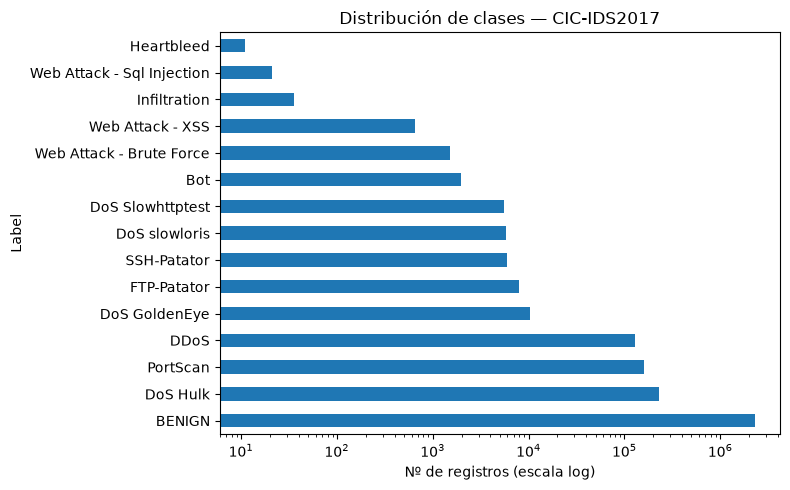

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
df["Label"].value_counts().plot(kind="barh", ax=ax, logx=True)
ax.set_xlabel("Nº de registros (escala log)")
ax.set_title("Distribución de clases — CIC-IDS2017")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "class_distribution.png", dpi=120)
plt.show()


### 1.2 Split estratificado train/val/test

El dataset tiene clases extremadamente raras (p. ej. `Heartbleed` con 11 filas en todo el
dataset completo). Un `train_test_split` estratificado estándar puede dejar 0 muestras de esas
clases en validación o test. `stratified_split_with_min_per_class` garantiza al menos 1 muestra
en cada split cuando la clase tiene 3 o más filas; si tiene menos de 3, todas sus filas van a
train (no hay forma de evaluarla de forma confiable) y se deja constancia en un warning.


In [11]:
def stratified_split_with_min_per_class(df, label_col, val_frac, test_frac, seed):
    train_idx, val_idx, test_idx, warnings = [], [], [], []
    rng = np.random.RandomState(seed)
    for label, group in df.groupby(label_col):
        idx = group.index.to_numpy().copy()
        rng.shuffle(idx)
        n = len(idx)
        if n < 3:
            train_idx.extend(idx)
            warnings.append(f"clase '{label}' tiene solo {n} fila(s); todas van a train")
            continue
        n_val = max(1, round(n * val_frac))
        n_test = max(1, round(n * test_frac))
        if n_val + n_test >= n:
            n_val, n_test = 1, 1
        test_idx.extend(idx[:n_test])
        val_idx.extend(idx[n_test:n_test + n_val])
        train_idx.extend(idx[n_test + n_val:])
    train_df = df.loc[train_idx].sample(frac=1, random_state=seed).reset_index(drop=True)
    val_df = df.loc[val_idx].sample(frac=1, random_state=seed).reset_index(drop=True)
    test_df = df.loc[test_idx].sample(frac=1, random_state=seed).reset_index(drop=True)
    return train_df, val_df, test_df, warnings


train_df, val_df, test_df, split_warnings = stratified_split_with_min_per_class(
    df, "Label", CONFIG["val_frac"], CONFIG["test_frac"], CONFIG["seed"]
)
print("train/val/test:", len(train_df), len(val_df), len(test_df))
for w in split_warnings:
    print("WARNING:", w)


train/val/test: 1981517 424613 424613


In [12]:
FEATURE_COLS = [c for c in df.columns if c != "Label"]

label_encoder = LabelEncoder().fit(df["Label"])
scaler = StandardScaler().fit(train_df[FEATURE_COLS])

X_train = scaler.transform(train_df[FEATURE_COLS]).astype(np.float32)
X_val = scaler.transform(val_df[FEATURE_COLS]).astype(np.float32)
X_test = scaler.transform(test_df[FEATURE_COLS]).astype(np.float32)
y_train = label_encoder.transform(train_df["Label"])
y_val = label_encoder.transform(val_df["Label"])
y_test = label_encoder.transform(test_df["Label"])
CLASS_NAMES = label_encoder.classes_
N_CLASSES = len(CLASS_NAMES)

train_df[FEATURE_COLS].assign(Label=train_df["Label"]).to_parquet(PROCESSED_DIR / "train.parquet", index=False)
val_df[FEATURE_COLS].assign(Label=val_df["Label"]).to_parquet(PROCESSED_DIR / "val.parquet", index=False)
test_df[FEATURE_COLS].assign(Label=test_df["Label"]).to_parquet(PROCESSED_DIR / "test.parquet", index=False)
joblib.dump(scaler, PROCESSED_DIR / "scaler.joblib")
joblib.dump(label_encoder, PROCESSED_DIR / "label_encoder.joblib")
(PROCESSED_DIR / "feature_names.json").write_text(json.dumps(FEATURE_COLS, indent=2))

dataset_card = {
    "n_rows_total": int(len(df)),
    "n_features": len(FEATURE_COLS),
    "n_classes": N_CLASSES,
    "class_counts": df["Label"].value_counts().to_dict(),
    "split_sizes": {"train": len(train_df), "val": len(val_df), "test": len(test_df)},
    "split_warnings": split_warnings,
    "fast_dev_run": CONFIG["fast_dev_run"],
}
(PROCESSED_DIR / "dataset_card.json").write_text(json.dumps(dataset_card, indent=2))
print("Artefactos de datos guardados en", PROCESSED_DIR)


Artefactos de datos guardados en d:\Github\Tareas-Deep-Learning\Tarea_1\notebooks\local_run\IDS_Tarea1\data\processed\full


### 1.3 Baseline: Regresión Logística + SVM (RBF)

- **Regresión Logística**: rápida, se entrena sobre todo el train disponible. `class_weight="balanced"`
  para compensar el desbalance extremo de clases.
- **SVM kernel RBF**: un SVC con kernel es O(n²)-O(n³), inviable sobre el dataset completo. Se
  entrena sobre una submuestra (`CONFIG["svm_train_size"]`). Se eligió **RBF y no un SVM lineal**
  a propósito: el objetivo de esta sección es evidenciar relaciones no lineales, y un modelo
  lineal las ocultaría por diseño.

Métrica principal: **macro-F1** (no accuracy), porque con este desbalance un modelo que
prediga casi siempre `BENIGN` tendría accuracy alta pero sería inútil para detectar ataques raros.


In [13]:
t0 = time.time()
logreg = LogisticRegression(max_iter=300, class_weight="balanced")
logreg.fit(X_train, y_train)
logreg_time = time.time() - t0
pred_lr = logreg.predict(X_test)

lr_metrics = {
    "macro_f1": float(f1_score(y_test, pred_lr, average="macro")),
    "balanced_accuracy": float(balanced_accuracy_score(y_test, pred_lr)),
    "train_time_s": logreg_time,
    "n_train_rows": len(X_train),
}
print("Regresión Logística:", lr_metrics)


Regresión Logística: {'macro_f1': 0.41558396716893387, 'balanced_accuracy': 0.8625684523847615, 'train_time_s': 402.8368787765503, 'n_train_rows': 1981517}


c:\Users\21474919K\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


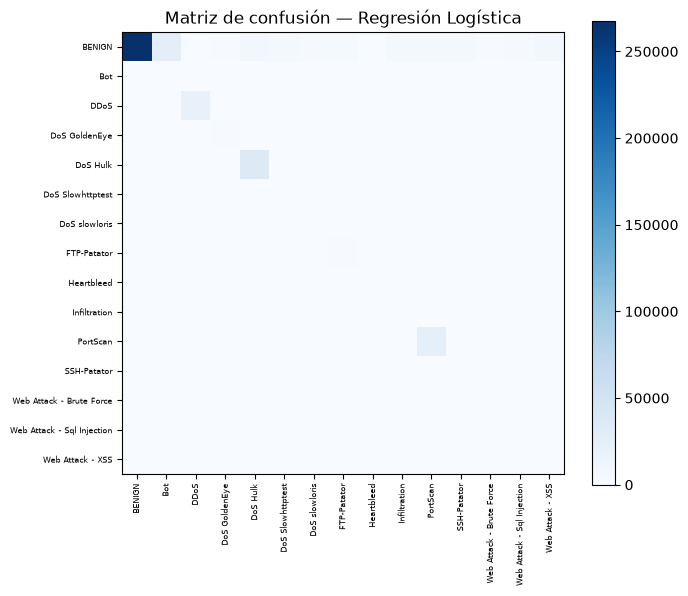

In [14]:
def plot_confusion(y_true, y_pred, class_names, title, out_path):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=90, fontsize=6)
    ax.set_yticklabels(class_names, fontsize=6)
    ax.set_title(title)
    fig.colorbar(im)
    fig.tight_layout()
    fig.savefig(out_path, dpi=120)
    plt.show()
    return cm


_ = plot_confusion(y_test, pred_lr, CLASS_NAMES, "Matriz de confusión — Regresión Logística",
                    RESULTS_DIR / "confusion_matrix_logreg.png")


SVM (RBF): {'macro_f1': 0.3612941161547533, 'balanced_accuracy': 0.6077871345377324, 'train_time_s': 1.1599321365356445, 'n_train_rows': 4000}


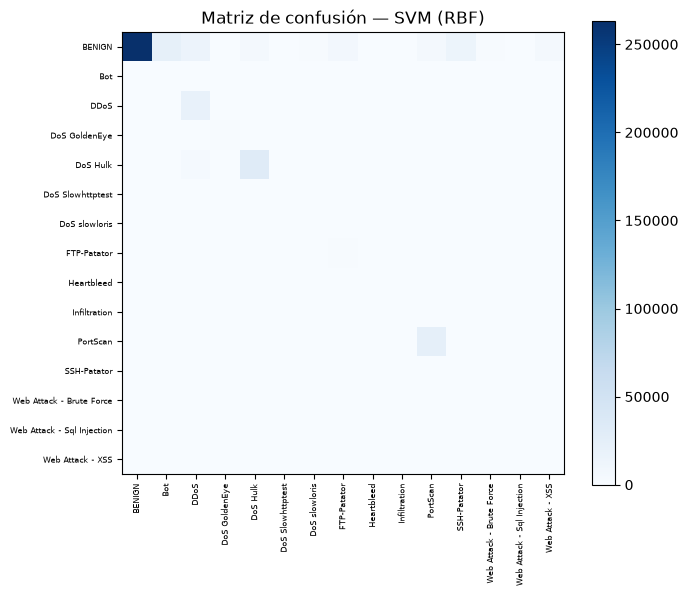

In [15]:
rng = np.random.RandomState(CONFIG["seed"])
svm_n = min(CONFIG["svm_train_size"], len(X_train))
svm_idx = rng.choice(len(X_train), size=svm_n, replace=False)

t0 = time.time()
svm = SVC(kernel="rbf", class_weight="balanced")
svm.fit(X_train[svm_idx], y_train[svm_idx])
svm_time = time.time() - t0
pred_svm = svm.predict(X_test)

svm_metrics = {
    "macro_f1": float(f1_score(y_test, pred_svm, average="macro")),
    "balanced_accuracy": float(balanced_accuracy_score(y_test, pred_svm)),
    "train_time_s": svm_time,
    "n_train_rows": int(svm_n),
}
print("SVM (RBF):", svm_metrics)
_ = plot_confusion(y_test, pred_svm, CLASS_NAMES, "Matriz de confusión — SVM (RBF)",
                    RESULTS_DIR / "confusion_matrix_svm.png")


### 1.4 Limitaciones del baseline: evidencia experimental

Tres piezas de evidencia:

1. **Curva de aprendizaje** de la Regresión Logística: si el gap train/val no se cierra al
   agregar más datos, el problema no es falta de datos sino falta de capacidad/expresividad del
   modelo lineal.
2. **Regiones de error en el espacio de entrada** (proyección PCA 2D): dónde se concentran los
   errores de clasificación del baseline.
3. **Comparación con un modelo no lineal (Gradient Boosting superficial)** entrenado sobre la
   misma submuestra que el SVM: si el GBM supera claramente a la Regresión Logística con los
   mismos datos, es evidencia de relaciones no lineales / interacciones entre features que el
   modelo lineal no captura.


c:\Users\21474919K\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\21474919K\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https

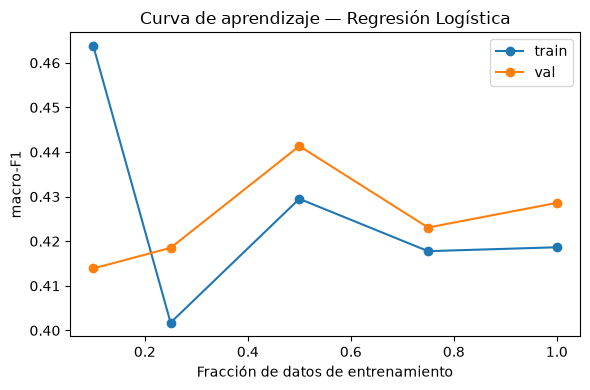

In [16]:
fractions = [0.1, 0.25, 0.5, 0.75, 1.0]
train_scores, val_scores = [], []
for frac in fractions:
    n = max(50, int(len(X_train) * frac))
    idx = rng.choice(len(X_train), size=n, replace=False)
    m = LogisticRegression(max_iter=300, class_weight="balanced")
    m.fit(X_train[idx], y_train[idx])
    train_scores.append(f1_score(y_train[idx], m.predict(X_train[idx]), average="macro"))
    val_scores.append(f1_score(y_val, m.predict(X_val), average="macro"))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(fractions, train_scores, marker="o", label="train")
ax.plot(fractions, val_scores, marker="o", label="val")
ax.set_xlabel("Fracción de datos de entrenamiento")
ax.set_ylabel("macro-F1")
ax.set_title("Curva de aprendizaje — Regresión Logística")
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "learning_curve_logreg.png", dpi=120)
plt.show()


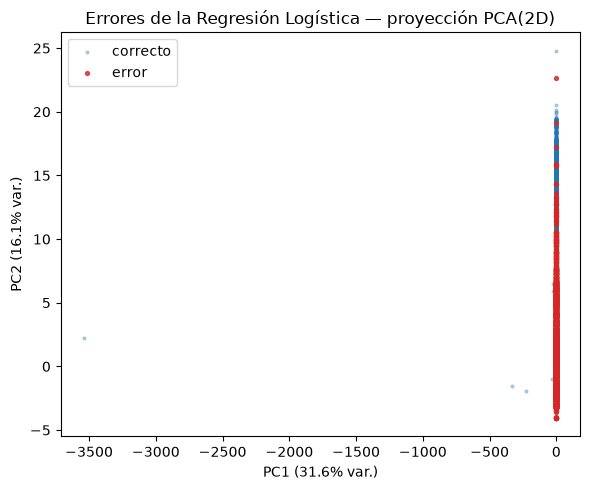

In [17]:
pca = PCA(n_components=2, random_state=CONFIG["seed"])
X_test_2d = pca.fit_transform(X_test)
correct = pred_lr == y_test

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_test_2d[correct, 0], X_test_2d[correct, 1], s=4, alpha=0.3, c="tab:blue", label="correcto")
ax.scatter(X_test_2d[~correct, 0], X_test_2d[~correct, 1], s=8, alpha=0.8, c="tab:red", label="error")
ax.set_title("Errores de la Regresión Logística — proyección PCA(2D)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var.)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var.)")
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "pca_error_regions.png", dpi=120)
plt.show()


In [18]:
gbm = GradientBoostingClassifier(n_estimators=60, max_depth=3, random_state=CONFIG["seed"])
gbm.fit(X_train[svm_idx], y_train[svm_idx])
pred_gbm = gbm.predict(X_test)
gbm_metrics = {
    "macro_f1": float(f1_score(y_test, pred_gbm, average="macro")),
    "balanced_accuracy": float(balanced_accuracy_score(y_test, pred_gbm)),
    "n_train_rows": int(svm_n),
}
print("Gradient Boosting (misma submuestra que SVM):", gbm_metrics)
print("Regresión Logística, misma cantidad de filas de train ~equivalente:", lr_metrics["macro_f1"])
print("\nDelta GBM - LR (evidencia de no-linealidad si es claramente positivo):",
      round(gbm_metrics["macro_f1"] - lr_metrics["macro_f1"], 4))


Gradient Boosting (misma submuestra que SVM): {'macro_f1': 0.6006912917443717, 'balanced_accuracy': 0.5981994483986749, 'n_train_rows': 4000}
Regresión Logística, misma cantidad de filas de train ~equivalente: 0.41558396716893387

Delta GBM - LR (evidencia de no-linealidad si es claramente positivo): 0.1851


### 1.5 Diseño e implementación de la DNN (PyTorch)

Decisiones de diseño justificadas por el análisis anterior:

- **No lineal por capas** (MLP con ReLU): el GBM superó claramente a la Regresión Logística con
  los mismos datos → hay relaciones no lineales / interacciones entre features que un modelo
  lineal no captura, así que la arquitectura debe poder representarlas.
- **BatchNorm + Dropout**: el dataset tiene features en escalas muy distintas (duraciones,
  bytes, conteos) y clases con pocas muestras — BatchNorm estabiliza el entrenamiento y Dropout
  reduce sobreajuste en las clases minoritarias.
- **Loss ponderada por clase** (`class_weight` vía `compute_class_weight`): mismo problema de
  desbalance que en el baseline.
- **Early stopping sobre macro-F1 de validación**: evita sobreajustar y controla el costo de
  entrenamiento — relevante para la comparación de costo computacional de la Parte 2.


In [19]:
class DNNClassifier(nn.Module):
    def __init__(self, input_dim, n_classes, hidden_dims=(128, 64, 32), dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.BatchNorm1d(h), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [20]:
def train_dnn(X_train, y_train, X_val, y_val, n_classes, dnn_config, device, seed):
    torch.manual_seed(seed)
    model = DNNClassifier(
        input_dim=X_train.shape[1],
        n_classes=n_classes,
        hidden_dims=dnn_config["hidden_dims"],
        dropout=dnn_config["dropout"],
    ).to(device)

    class_weights = compute_class_weight("balanced", classes=np.arange(n_classes), y=y_train)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32, device=device))
    optimizer = torch.optim.Adam(model.parameters(), lr=dnn_config["lr"])

    X_train_t = torch.tensor(X_train)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    X_val_t = torch.tensor(X_val).to(device)
    y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)

    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_train_t, y_train_t),
        batch_size=dnn_config["batch_size"], shuffle=True,
    )

    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
    best_val_f1, best_state, patience_left = -1.0, None, dnn_config["patience"]

    for epoch in range(dnn_config["max_epochs"]):
        model.train()
        batch_losses = []
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            train_pred = model(X_train_t.to(device)).argmax(1).cpu().numpy()
            val_logits = model(X_val_t)
            val_loss = criterion(val_logits, y_val_t).item()
            val_pred = val_logits.argmax(1).cpu().numpy()

        train_f1 = f1_score(y_train, train_pred, average="macro")
        val_f1 = f1_score(y_val, val_pred, average="macro")
        history["train_loss"].append(float(np.mean(batch_losses)))
        history["val_loss"].append(val_loss)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1, patience_left = val_f1, dnn_config["patience"]
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_left -= 1

        if epoch % 5 == 0:
            print(f"epoch {epoch:>3}: train_loss={history['train_loss'][-1]:.4f} "
                  f"val_loss={val_loss:.4f} train_f1={train_f1:.4f} val_f1={val_f1:.4f}")
        if patience_left == 0:
            print(f"Early stopping en epoch {epoch} (mejor val_f1={best_val_f1:.4f})")
            break

    model.load_state_dict(best_state)
    return model, history, best_val_f1


In [21]:
dnn_checkpoint_path = RESULTS_DIR / "dnn.pt"

dnn_model, dnn_history, dnn_best_val_f1 = train_dnn(
    X_train, y_train, X_val, y_val, N_CLASSES, CONFIG["dnn"], DEVICE, CONFIG["seed"]
)
torch.save(dnn_model.state_dict(), dnn_checkpoint_path)
print("Checkpoint guardado en", dnn_checkpoint_path)


epoch   0: train_loss=0.4973 val_loss=1.2391 train_f1=0.4428 val_f1=0.4432
epoch   5: train_loss=0.2175 val_loss=1.3369 train_f1=0.4912 val_f1=0.4904
epoch  10: train_loss=0.1954 val_loss=1.2417 train_f1=0.5115 val_f1=0.5129
epoch  15: train_loss=0.1862 val_loss=0.6057 train_f1=0.5442 val_f1=0.5224
epoch  20: train_loss=0.1837 val_loss=0.9745 train_f1=0.5418 val_f1=0.5255
epoch  25: train_loss=0.1741 val_loss=0.8121 train_f1=0.5512 val_f1=0.5492
epoch  30: train_loss=0.1744 val_loss=0.6025 train_f1=0.5387 val_f1=0.5304
epoch  35: train_loss=0.1682 val_loss=0.6436 train_f1=0.5759 val_f1=0.5681
epoch  40: train_loss=0.1638 val_loss=0.8918 train_f1=0.6167 val_f1=0.5976
Early stopping en epoch 40 (mejor val_f1=0.5988)
Checkpoint guardado en d:\Github\Tareas-Deep-Learning\Tarea_1\notebooks\local_run\IDS_Tarea1\results\parte1\dnn.pt


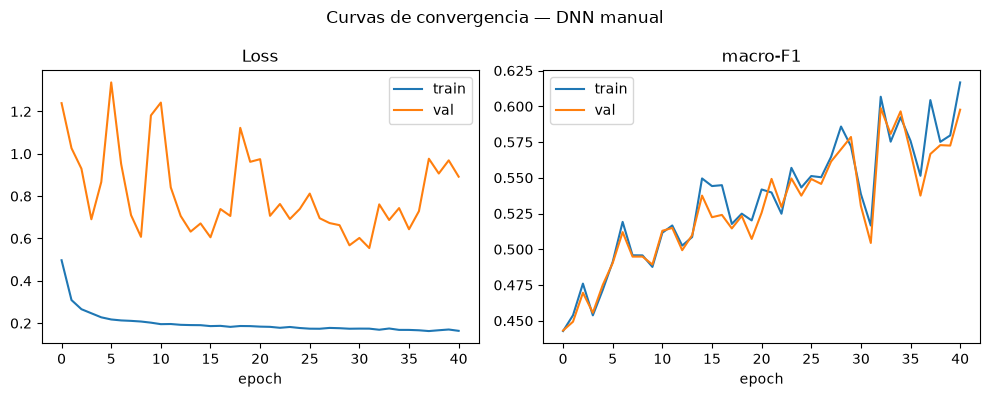

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(dnn_history["train_loss"], label="train")
axes[0].plot(dnn_history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[1].plot(dnn_history["train_f1"], label="train")
axes[1].plot(dnn_history["val_f1"], label="val")
axes[1].set_title("macro-F1")
axes[1].set_xlabel("epoch")
axes[1].legend()
fig.suptitle("Curvas de convergencia — DNN manual")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "dnn_convergence.png", dpi=120)
plt.show()


DNN (test): {'macro_f1': 0.6042637823566253, 'balanced_accuracy': 0.8492124809439713, 'best_val_macro_f1': 0.598751210778164, 'n_params': 21263, 'epochs_run': 41}


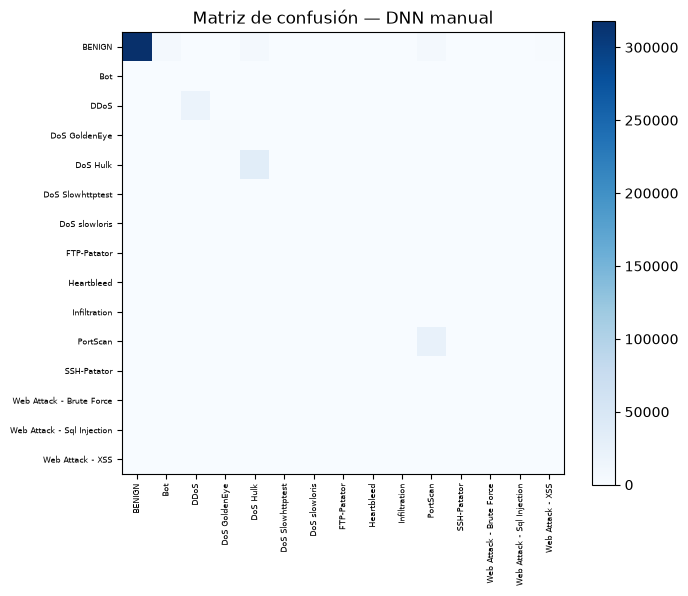

In [23]:
dnn_model.eval()
with torch.no_grad():
    test_pred = dnn_model(torch.tensor(X_test).to(DEVICE)).argmax(1).cpu().numpy()

dnn_metrics = {
    "macro_f1": float(f1_score(y_test, test_pred, average="macro")),
    "balanced_accuracy": float(balanced_accuracy_score(y_test, test_pred)),
    "best_val_macro_f1": float(dnn_best_val_f1),
    "n_params": int(sum(p.numel() for p in dnn_model.parameters())),
    "epochs_run": len(dnn_history["train_loss"]),
}
print("DNN (test):", dnn_metrics)
_ = plot_confusion(y_test, test_pred, CLASS_NAMES, "Matriz de confusión — DNN manual",
                    RESULTS_DIR / "confusion_matrix_dnn.png")


### 1.6 Resumen Parte 1

Tabla comparativa preliminar (la comparación completa con AutoML/NAS se arma en la Parte 2, que
reutiliza estos mismos artefactos y esta misma clase `DNNClassifier`).


In [24]:
summary_parte1 = {
    "config": CONFIG,
    "dataset_card": dataset_card,
    "logistic_regression": lr_metrics,
    "svm_rbf": svm_metrics,
    "gbm_reference_same_subsample_as_svm": gbm_metrics,
    "dnn_manual": dnn_metrics,
}
(RESULTS_DIR / "metrics.json").write_text(json.dumps(summary_parte1, indent=2, default=str))

comparison = pd.DataFrame([
    {"modelo": "Regresión Logística", "macro_f1": lr_metrics["macro_f1"], "n_train": lr_metrics["n_train_rows"], "tiempo_s": lr_metrics["train_time_s"]},
    {"modelo": "SVM (RBF)", "macro_f1": svm_metrics["macro_f1"], "n_train": svm_metrics["n_train_rows"], "tiempo_s": svm_metrics["train_time_s"]},
    {"modelo": "DNN manual", "macro_f1": dnn_metrics["macro_f1"], "n_train": len(X_train), "tiempo_s": None},
])
comparison


,modelo,macro_f1,n_train,tiempo_s
0,Regresión Logística,0.415584,1981517,402.836879
1,SVM (RBF),0.361294,4000,1.159932
2,DNN manual,0.604264,1981517,NaN


## Parte 2 — AutoML + NAS

Reutiliza en memoria todo lo definido en la Parte 1: `X_train/val/test`, `y_train/val/test`,
`CLASS_NAMES`, `N_CLASSES`, `DEVICE`, la clase `DNNClassifier` y la función `plot_confusion`.
No se recarga ni se reprocesa ningún dato.

### 2.1 AutoML: búsqueda de una técnica de ML de baja complejidad (FLAML)

Se restringe `estimator_list` a técnicas de baja complejidad (regresión logística regularizada,
k-NN, un árbol "extra") y se desactiva el ensamblado (`ensemble=False`): el enunciado pide *una*
técnica de baja complejidad encontrada automáticamente, no un stack de varios modelos. La métrica
de selección es macro-F1 (igual que en toda la comparación), evaluada con el mismo split de
validación que usa la DNN.


In [25]:
try:
    from flaml import AutoML
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "flaml"], check=True)
    from flaml import AutoML

RESULTS_DIR_P2 = DRIVE_ROOT / "results" / "parte2"
RESULTS_DIR_P2.mkdir(parents=True, exist_ok=True)


c:\Users\21474919K\AppData\Local\Programs\Python\Python313\Lib\site-packages\flaml\__init__.py:20: UserWarning: flaml.automl is not available. Please install flaml[automl] to enable AutoML functionalities.
  warnings.warn("flaml.automl is not available. Please install flaml[automl] to enable AutoML functionalities.")


ImportError: cannot import name 'AutoML' from 'flaml' (c:\Users\21474919K\AppData\Local\Programs\Python\Python313\Lib\site-packages\flaml\__init__.py)

/tmp/claude-1000/-home-alex-Git-Tareas-Deep-Learning/6c8135b8-1a85-444f-8550-9b87c98d04c9/scratchpad/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/tmp/claude-1000/-home-alex-Git-Tareas-Deep-Learning/6c8135b8-1a85-444f-8550-9b87c98d04c9/scratchpad/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/tmp/claude-1000/-home-alex-Git-Tareas-Deep-Learning/6c8135b8-1a85-444f-8550-9b87c98d04c9/scratchpad/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/tmp/claude-1000/-home-alex-Git-Tareas-Deep-Learning/6c8135b8-1a85-444f-8550-9b87c98d04c9/scratchpad/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/tmp/claude-1000/-home-alex-Git-Tareas-Deep-Learning/6c8135b8-1a85-444f-8550-9b87c98d04c9/scratchpad/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/tmp/claude-1000/-home-alex-Git-Tareas-Deep-Learning/6c8135b8-1a85-444f-8550-9b87c98d04c9/scratchpad/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/tmp/claude-1000/-home-alex-Git-Tareas-Deep-Learning/6c8135b8-1a85-444f-8550-9b87c98d04c9/scratchpad/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/tmp/claude-1000/-home-alex-Git-Tareas-Deep-Learning/6c8135b8-1a85-444f-8550-9b87c98d04c9/scratchpad/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/tmp/claude-1000/-home-alex-Git-Tareas-Deep-Learning/6c8135b8-1a85-444f-8550-9b87c98d04c9/scratchpad/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/tmp/claude-1000/-home-alex-Git-Tareas-Deep-Learning/6c8135b8-1a85-444f-8550-9b87c98d04c9/scratchpad/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/tmp/claude-1000/-home-alex-Git-Tareas-Deep-Learning/6c8135b8-1a85-444f-8550-9b87c98d04c9/scratchpad/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/tmp/claude-1000/-home-alex-Git-Tareas-Deep-Learning/6c8135b8-1a85-444f-8550-9b87c98d04c9/scratchpad/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/tmp/claude-1000/-home-alex-Git-Tareas-Deep-Learning/6c8135b8-1a85-444f-8550-9b87c98d04c9/scratchpad/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/tmp/claude-1000/-home-alex-Git-Tareas-Deep-Learning/6c8135b8-1a85-444f-8550-9b87c98d04c9/scratchpad/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/tmp/claude-1000/-home-alex-Git-Tareas-Deep-Learning/6c8135b8-1a85-444f-8550-9b87c98d04c9/scratchpad/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/tmp/claude-1000/-home-alex-Git-Tareas-Deep-Learning/6c8135b8-1a85-444f-8550-9b87c98d04c9/scratchpad/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


AutoML (FLAML): {'best_estimator': 'extra_tree', 'best_config': {'n_estimators': 4, 'max_features': np.float64(0.24835685705273347), 'max_leaves': 259, 'criterion': np.str_('entropy')}, 'macro_f1': 0.8848369061176241, 'balanced_accuracy': 0.8923507180650038, 'train_time_s': 29.89416742324829}


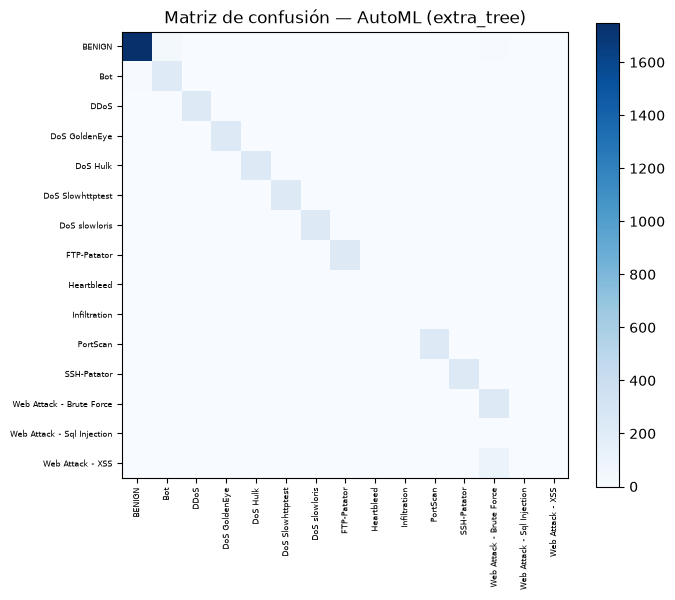

In [ ]:
def run_flaml_automl(X_tr, y_tr, X_va, y_va, X_te, y_te, automl_cfg, seed):
    """Reutilizada tal cual en la Parte 3 sobre el train aumentado."""
    automl = AutoML()
    t0 = time.time()
    automl.fit(
        X_train=X_tr, y_train=y_tr,
        X_val=X_va, y_val=y_va,
        task="classification",
        metric="macro_f1",
        estimator_list=automl_cfg["estimator_list"],
        ensemble=automl_cfg["ensemble"],
        time_budget=automl_cfg["time_budget_s"],
        seed=seed,
        verbose=0,
    )
    train_time = time.time() - t0
    pred = automl.predict(X_te)
    metrics = {
        "best_estimator": automl.best_estimator,
        "best_config": automl.best_config,
        "macro_f1": float(f1_score(y_te, pred, average="macro")),
        "balanced_accuracy": float(balanced_accuracy_score(y_te, pred)),
        "train_time_s": train_time,
    }
    return automl, pred, metrics


automl, pred_automl, automl_metrics = run_flaml_automl(
    X_train, y_train, X_val, y_val, X_test, y_test, CONFIG["automl"], CONFIG["seed"]
)
print("AutoML (FLAML):", automl_metrics)
_ = plot_confusion(y_test, pred_automl, CLASS_NAMES, f"Matriz de confusión — AutoML ({automl.best_estimator})",
                    RESULTS_DIR_P2 / "confusion_matrix_automl.png")


### 2.2 NAS: optimización de la arquitectura de la DNN manual (Optuna)

Optuna busca sobre el **mismo espacio de arquitectura** de la `DNNClassifier` definida en la
Parte 1 (número de capas, unidades por capa, dropout, learning rate). Cada trial entrena una
versión corta (`search_max_epochs`, `search_patience`) para que la búsqueda sea rápida; una vez
encontrada la mejor configuración, se reentrena con el presupuesto completo
(`final_max_epochs`, `final_patience`) — mismo criterio de early stopping que en 1.5.


In [ ]:
try:
    import optuna
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "optuna"], check=True)
    import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


In [ ]:
def sample_dnn_config(trial, nas_cfg, base_dnn_cfg):
    n_layers = trial.suggest_int("n_layers", 1, nas_cfg["max_layers"])
    hidden_dims = tuple(
        trial.suggest_categorical(f"units_l{i}", nas_cfg["hidden_dim_choices"])
        for i in range(n_layers)
    )
    dropout = trial.suggest_float("dropout", *nas_cfg["dropout_range"])
    lr = trial.suggest_float("lr", *nas_cfg["lr_range"], log=True)
    return {
        **base_dnn_cfg,
        "hidden_dims": hidden_dims,
        "dropout": dropout,
        "lr": lr,
        "max_epochs": nas_cfg["search_max_epochs"],
        "patience": nas_cfg["search_patience"],
    }


def make_nas_objective(X_tr, y_tr, X_va, y_va, n_classes, nas_cfg, base_dnn_cfg, device, seed):
    """Factory: devuelve una función objetivo de Optuna atada a un dataset dado.
    Se reutiliza tal cual en la Parte 3 sobre el train aumentado."""
    def objective(trial):
        dnn_cfg = sample_dnn_config(trial, nas_cfg, base_dnn_cfg)
        _, _, val_f1 = train_dnn(X_tr, y_tr, X_va, y_va, n_classes, dnn_cfg, device, seed)
        return val_f1
    return objective


nas_objective = make_nas_objective(X_train, y_train, X_val, y_val, N_CLASSES, CONFIG["nas"], CONFIG["dnn"], DEVICE, CONFIG["seed"])

t0 = time.time()
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=CONFIG["seed"]))
study.optimize(nas_objective, n_trials=CONFIG["nas"]["n_trials"], show_progress_bar=False)
nas_search_time = time.time() - t0
print("Mejor configuración encontrada:", study.best_params)
print("Mejor macro-F1 de validación (búsqueda corta):", study.best_value)
print(f"Tiempo de búsqueda: {nas_search_time:.1f}s ({CONFIG['nas']['n_trials']} trials)")


epoch   0: train_loss=3.2858 val_loss=3.1383 train_f1=0.0763 val_f1=0.0792


epoch   5: train_loss=2.4556 val_loss=2.1691 train_f1=0.3870 val_f1=0.4017


epoch  10: train_loss=2.0464 val_loss=1.8205 train_f1=0.4139 val_f1=0.4043
Early stopping en epoch 10 (mejor val_f1=0.4196)


epoch   0: train_loss=2.1752 val_loss=1.4088 train_f1=0.4632 val_f1=0.4552


epoch   5: train_loss=0.9315 val_loss=0.6215 train_f1=0.6232 val_f1=0.6007


...

epoch  10: train_loss=1.1675 val_loss=1.2236 train_f1=0.5083 val_f1=0.4849


epoch   0: train_loss=2.2811 val_loss=1.6605 train_f1=0.4873 val_f1=0.4616


epoch   5: train_loss=1.0070 val_loss=0.6671 train_f1=0.6446 val_f1=0.6481


epoch  10: train_loss=0.7801 val_loss=0.4962 train_f1=0.6879 val_f1=0.6843


Mejor configuración encontrada: {'n_layers': 1, 'units_l0': 64, 'dropout': 0.14046725484369038, 'lr': 0.001217284708112243}
Mejor macro-F1 de validación (búsqueda corta): 0.7662441313010812
Tiempo de búsqueda: 55.6s (8 trials)


epoch   0: train_loss=1.9920 val_loss=1.1269 train_f1=0.4874 val_f1=0.4816


epoch   5: train_loss=0.4660 val_loss=0.4405 train_f1=0.7048 val_f1=0.6969


epoch  10: train_loss=0.3427 val_loss=0.3808 train_f1=0.7602 val_f1=0.7662


epoch  15: train_loss=0.3165 val_loss=0.3344 train_f1=0.7387 val_f1=0.7365


Early stopping en epoch 18 (mejor val_f1=0.7662)
DNN-NAS (test): {'hidden_dims': [64], 'dropout': 0.14046725484369038, 'lr': 0.001217284708112243, 'macro_f1': 0.7649497733149334, 'balanced_accuracy': 0.8514346182917613, 'best_val_macro_f1': 0.7662441313010812, 'n_params': 6095, 'epochs_run': 19, 'search_time_s': 55.550418853759766, 'final_train_time_s': 8.949893712997437}


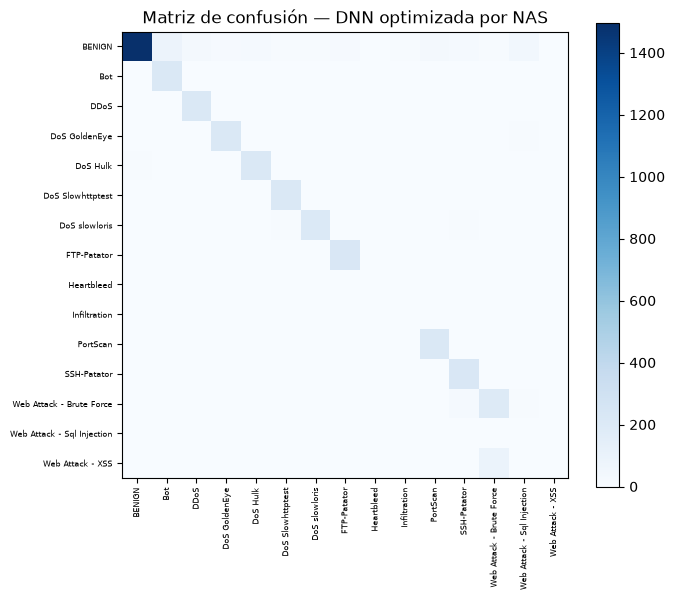

In [ ]:
def refit_best_nas_dnn(study, nas_cfg, base_dnn_cfg, X_tr, y_tr, X_va, y_va, X_te, y_te,
                        n_classes, device, seed, search_time_s, checkpoint_path):
    """Reentrena con presupuesto completo la mejor configuración encontrada por Optuna.
    Reutilizada tal cual en la Parte 3 sobre el train aumentado."""
    n_layers = study.best_params["n_layers"]
    hidden_dims = tuple(study.best_params[f"units_l{i}"] for i in range(n_layers))
    best_dnn_cfg = {
        **base_dnn_cfg,
        "hidden_dims": hidden_dims,
        "dropout": study.best_params["dropout"],
        "lr": study.best_params["lr"],
        "max_epochs": nas_cfg["final_max_epochs"],
        "patience": nas_cfg["final_patience"],
    }

    t0 = time.time()
    model, history, best_val_f1 = train_dnn(X_tr, y_tr, X_va, y_va, n_classes, best_dnn_cfg, device, seed)
    train_time = time.time() - t0
    torch.save(model.state_dict(), checkpoint_path)

    model.eval()
    with torch.no_grad():
        pred = model(torch.tensor(X_te).to(device)).argmax(1).cpu().numpy()

    metrics = {
        "hidden_dims": list(hidden_dims),
        "dropout": best_dnn_cfg["dropout"],
        "lr": best_dnn_cfg["lr"],
        "macro_f1": float(f1_score(y_te, pred, average="macro")),
        "balanced_accuracy": float(balanced_accuracy_score(y_te, pred)),
        "best_val_macro_f1": float(best_val_f1),
        "n_params": int(sum(p.numel() for p in model.parameters())),
        "epochs_run": len(history["train_loss"]),
        "search_time_s": search_time_s,
        "final_train_time_s": train_time,
    }
    return model, pred, metrics


nas_model, pred_nas, nas_metrics = refit_best_nas_dnn(
    study, CONFIG["nas"], CONFIG["dnn"], X_train, y_train, X_val, y_val, X_test, y_test,
    N_CLASSES, DEVICE, CONFIG["seed"], nas_search_time, RESULTS_DIR_P2 / "nas_dnn.pt",
)
print("DNN-NAS (test):", nas_metrics)
_ = plot_confusion(y_test, pred_nas, CLASS_NAMES, "Matriz de confusión — DNN optimizada por NAS",
                    RESULTS_DIR_P2 / "confusion_matrix_nas_dnn.png")


### 2.3 Tabla comparativa y discusión crítica

Se compara desempeño (macro-F1), complejidad/costo computacional (nº de parámetros o de reglas
del modelo, tiempo de entrenamiento) y una proxy de generalización (gap val→test de macro-F1:
qué tanto cae el desempeño de validación a test; valores cercanos a 0 indican buena
generalización).


In [ ]:
def gap(val_f1, test_f1):
    return None if val_f1 is None else round(val_f1 - test_f1, 4)

rows = [
    {"modelo": "Regresión Logística", "macro_f1_test": lr_metrics["macro_f1"], "n_params_o_reglas": X_train.shape[1] * N_CLASSES,
     "tiempo_entrenamiento_s": lr_metrics["train_time_s"], "gap_val_test": None},
    {"modelo": "SVM (RBF)", "macro_f1_test": svm_metrics["macro_f1"], "n_params_o_reglas": svm_metrics["n_train_rows"],
     "tiempo_entrenamiento_s": svm_metrics["train_time_s"], "gap_val_test": None},
    {"modelo": "DNN manual (Parte 1)", "macro_f1_test": dnn_metrics["macro_f1"], "n_params_o_reglas": dnn_metrics["n_params"],
     "tiempo_entrenamiento_s": None, "gap_val_test": gap(dnn_metrics["best_val_macro_f1"], dnn_metrics["macro_f1"])},
    {"modelo": f"AutoML — {automl_metrics['best_estimator']}", "macro_f1_test": automl_metrics["macro_f1"], "n_params_o_reglas": None,
     "tiempo_entrenamiento_s": automl_metrics["train_time_s"], "gap_val_test": None},
    {"modelo": "DNN + NAS (Optuna)", "macro_f1_test": nas_metrics["macro_f1"], "n_params_o_reglas": nas_metrics["n_params"],
     "tiempo_entrenamiento_s": nas_metrics["final_train_time_s"], "gap_val_test": gap(nas_metrics["best_val_macro_f1"], nas_metrics["macro_f1"])},
]
comparison_parte2 = pd.DataFrame(rows)
comparison_parte2.to_csv(RESULTS_DIR_P2 / "comparison_table.csv", index=False)

summary_parte2 = {
    "automl": automl_metrics,
    "nas_dnn": nas_metrics,
    "comparison_table": rows,
}
(RESULTS_DIR_P2 / "metrics.json").write_text(json.dumps(summary_parte2, indent=2, default=str))

comparison_parte2


,modelo,macro_f1_test,n_params_o_reglas,tiempo_entrenamiento_s,gap_val_test
0,Regresión Logística,0.726838,1155.0,3.450514,NaN
1,SVM (RBF),0.703991,4000.0,1.110446,NaN
2,DNN manual (Parte 1),0.752555,21263.0,NaN,0.0113
3,AutoML — extra_tree,0.884837,NaN,29.894167,NaN
4,DNN + NAS (Optuna),0.764950,6095.0,8.949894,0.0013


**Discusión (completar/ajustar con los números de la corrida final en el dataset completo):**

- Si el AutoML de baja complejidad (estimador elegido automáticamente por FLAML, ver
  `automl_metrics["best_estimator"]` arriba) queda cerca o por encima de la
  DNN manual en macro-F1, es evidencia de que, *para este problema*, la capacidad extra de una
  red profunda no se traduce necesariamente en mejor desempeño — su uso habría que justificarlo
  por otras razones (p. ej. facilidad de integrar más datos/features en el futuro), no por
  necesidad estadística pura.
- Si el NAS mejora meaningfully a la arquitectura manual con una cantidad de parámetros similar
  o menor, es evidencia de que el diseño manual dejó margen de mejora en la arquitectura; si el
  NAS converge a una arquitectura parecida a la manual, es evidencia de que las decisiones de
  diseño manual (Sección 1.5) ya estaban bien justificadas.
- El costo computacional de la búsqueda NAS/AutoML (`search_time_s` / `time_budget_s`) debe
  contrastarse contra la ganancia de desempeño obtenida: si la ganancia es marginal, el diseño
  manual sigue siendo la opción más eficiente en costo/beneficio.
- **Ojo si FLAML elige `kneighbor`**: un k-NN "entrena" instantáneo pero su costo de
  **inferencia** crece con el tamaño del train (compara contra todo el dataset en cada
  predicción). En la corrida rápida (~19k filas de train) puede ganar en macro-F1, pero eso no
  necesariamente se sostiene sobre el dataset completo (~2M+ filas de train): ahí el costo de
  inferencia por muestra sería órdenes de magnitud mayor que el de la DNN o el AutoML basado en
  árboles — un punto central para la discusión de "costo computacional" que pide el enunciado.


## Parte 3 — Datos sintéticos y aumento de entrenamiento

Reutiliza `train_df` (features en su escala original, antes de estandarizar), `FEATURE_COLS`,
`label_encoder`, `N_CLASSES`, `DEVICE`, `CLASS_NAMES`, y las funciones `train_dnn`,
`make_nas_objective`, `refit_best_nas_dnn`, `run_flaml_automl` y `plot_confusion` definidas en
las Partes 1 y 2 — nada se reimplementa.

`val_df`/`test_df` **no se tocan en ningún momento**: solo se usa dato sintético para aumentar
el *train*, tal como pide el enunciado.

### 3.1 Generación sintética (SDV — TVAE)

**Por qué TVAE**: es un autoencoder variacional para datos tabulares (encaja temáticamente con
el curso), bastante más rápido de entrenar que un GAN condicional (CTGAN) manteniendo buena
fidelidad de la distribución conjunta — un balance razonable dado el plazo de entrega.

**Por qué sobre-muestrear clases raras al armar la muestra de ajuste**: si se ajusta el TVAE
sobre la distribución real (`BENIGN` ≈ 62% de las filas, `Heartbleed` ≈ 0.05%), el modelo
aprende esa misma proporción y prácticamente nunca genera las clases raras — que es justamente
lo que se necesita para el aumento. Por eso la muestra de ajuste toma hasta
`sample_per_class_for_fit` filas por clase, **con reemplazo** para las clases con menos filas
que ese tope, de forma que el generador vea todas las clases con frecuencia comparable.


In [ ]:
try:
    from sdv.metadata import Metadata
    from sdv.single_table import TVAESynthesizer
    from sdv.evaluation.single_table import evaluate_quality
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "sdv"], check=True)
    from sdv.metadata import Metadata
    from sdv.single_table import TVAESynthesizer
    from sdv.evaluation.single_table import evaluate_quality

RESULTS_DIR_P3 = DRIVE_ROOT / "results" / "parte3"
RESULTS_DIR_P3.mkdir(parents=True, exist_ok=True)


/tmp/ipykernel_196949/3717927995.py:4: FutureWarning: The evaluation functions are now accessible via the 'sdv.evaluation' module.
  from sdv.evaluation.single_table import evaluate_quality


In [ ]:
syn_cfg = CONFIG["synthetic"]

_parts = []
for _, group in train_df.groupby("Label"):
    n = len(group)
    cap = syn_cfg["sample_per_class_for_fit"]
    _parts.append(group.sample(n=cap, replace=n < cap, random_state=CONFIG["seed"]))
tvae_fit_sample = pd.concat(_parts, ignore_index=True)[FEATURE_COLS + ["Label"]]
print("Muestra de ajuste del TVAE (balanceada por clase):", tvae_fit_sample.shape)
tvae_fit_sample["Label"].value_counts()


Muestra de ajuste del TVAE (balanceada por clase): (4500, 78)


Label
BENIGN                        300
Bot                           300
DDoS                          300
DoS GoldenEye                 300
DoS Hulk                      300
DoS Slowhttptest              300
DoS slowloris                 300
FTP-Patator                   300
Heartbleed                    300
Infiltration                  300
PortScan                      300
SSH-Patator                   300
Web Attack - Brute Force      300
Web Attack - Sql Injection    300
Web Attack - XSS              300
Name: count, dtype: int64

In [ ]:
sdv_metadata = Metadata.detect_from_dataframe(tvae_fit_sample, table_name="ids")
sdv_metadata.update_column(column_name="Label", table_name="ids", sdtype="categorical")

t0 = time.time()
tvae = TVAESynthesizer(sdv_metadata, epochs=syn_cfg["tvae_epochs"])
tvae.fit(tvae_fit_sample)
tvae_fit_time = time.time() - t0
print(f"TVAE entrenado en {tvae_fit_time:.1f}s sobre {len(tvae_fit_sample)} filas")


/tmp/claude-1000/-home-alex-Git-Tareas-Deep-Learning/6c8135b8-1a85-444f-8550-9b87c98d04c9/scratchpad/.venv/lib/python3.14/site-packages/sdv/single_table/base.py:139: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


TVAE entrenado en 85.4s sobre 4500 filas


In [ ]:
def sample_synthetic_pool(synthesizer, pool_size, n_rounds, seed):
    pools = []
    for i in range(n_rounds):
        pools.append(synthesizer.sample(num_rows=pool_size))
    return pd.concat(pools, ignore_index=True)


synthetic_pool = sample_synthetic_pool(tvae, syn_cfg["sample_pool_size"], 1, CONFIG["seed"])
print("Pool sintético inicial:", synthetic_pool.shape)
synthetic_pool["Label"].value_counts()


Pool sintético inicial: (3000, 78)


Label
Web Attack - Sql Injection    424
BENIGN                        422
DoS slowloris                 379
DDoS                          329
DoS Hulk                      287
Bot                           283
DoS GoldenEye                 225
Web Attack - Brute Force      146
FTP-Patator                   140
DoS Slowhttptest               95
Infiltration                   93
Web Attack - XSS               83
PortScan                       55
Heartbleed                     23
SSH-Patator                    16
Name: count, dtype: int64

### 3.2 Evaluación de fidelidad estadística

Tres chequeos independientes:

1. **Métricas SDV** (`evaluate_quality`): `Column Shapes` (qué tan parecidas son las
   distribuciones marginales, columna por columna — KSComplement para numéricas,
   TVComplement para categóricas) y `Column Pair Trends` (qué tan bien se preservan las
   correlaciones/relaciones entre pares de columnas).
2. **Comparación visual** de distribuciones marginales para las features con mayor varianza, y
   un heatmap de la diferencia de matrices de correlación (real vs. sintético).
3. **TSTR** (*Train on Synthetic, Test on Real*): entrenar un modelo simple solo con datos
   sintéticos y evaluarlo en el test real — si el desempeño se acerca al de entrenar con datos
   reales, los datos sintéticos capturan señal útil para la tarea real, no solo estadísticas
   superficiales.


In [ ]:
quality_report = evaluate_quality(tvae_fit_sample, synthetic_pool, sdv_metadata, verbose=False)
fidelity_summary = {
    "overall_score": quality_report.get_score(),
    "properties": quality_report.get_properties().to_dict(orient="records"),
}
print("Score de calidad SDV (0-1, mayor es mejor):", fidelity_summary["overall_score"])
quality_report.get_properties()


Score de calidad SDV (0-1, mayor es mejor): 0.8100838860443641


,Property,Score
0,Column Shapes,0.782509
1,Column Pair Trends,0.837659


In [ ]:
col_shapes = quality_report.get_details("Column Shapes")
worst_cols = col_shapes.sort_values("Score").head(8)
print("Columnas donde el TVAE reproduce peor la distribución marginal:")
worst_cols


Columnas donde el TVAE reproduce peor la distribución marginal:


,Table,Column,Metric,Score
7,ids,Fwd Packet Length Min,KSComplement,0.485889
36,ids,Fwd Packets/s,KSComplement,0.496556
15,ids,Flow Packets/s,KSComplement,0.497889
19,ids,Flow IAT Min,KSComplement,0.528333
24,ids,Fwd IAT Min,KSComplement,0.532556
70,ids,Active Std,KSComplement,0.556778
0,ids,Destination Port,KSComplement,0.581111
72,ids,Active Min,KSComplement,0.595444


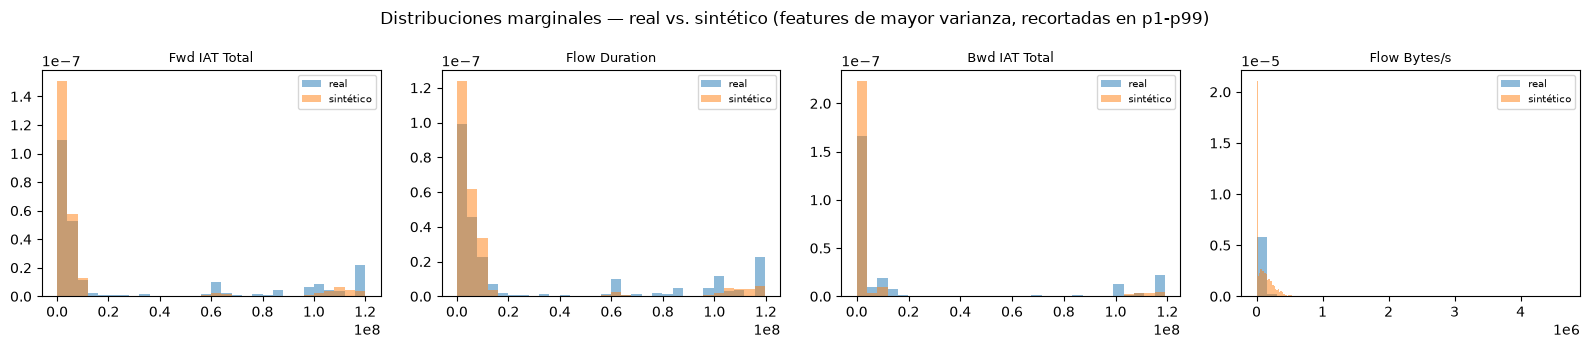

In [ ]:
top_var_cols = tvae_fit_sample[FEATURE_COLS].var().sort_values(ascending=False).head(4).index.tolist()
fig, axes = plt.subplots(1, len(top_var_cols), figsize=(4 * len(top_var_cols), 3.5))
for ax, col in zip(axes, top_var_cols):
    real_vals = tvae_fit_sample[col].clip(lower=tvae_fit_sample[col].quantile(0.01), upper=tvae_fit_sample[col].quantile(0.99))
    syn_vals = synthetic_pool[col].clip(lower=real_vals.min(), upper=real_vals.max())
    ax.hist(real_vals, bins=30, alpha=0.5, density=True, label="real")
    ax.hist(syn_vals, bins=30, alpha=0.5, density=True, label="sintético")
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)
fig.suptitle("Distribuciones marginales — real vs. sintético (features de mayor varianza, recortadas en p1-p99)")
fig.tight_layout()
fig.savefig(RESULTS_DIR_P3 / "marginal_distributions.png", dpi=120)
plt.show()


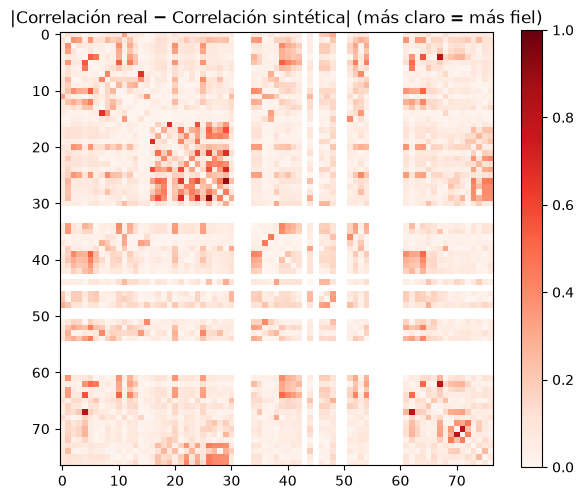

Diferencia media absoluta de correlación: 0.10550570612317735


In [ ]:
real_corr = tvae_fit_sample[FEATURE_COLS].corr()
syn_corr = synthetic_pool[FEATURE_COLS].corr()
corr_diff = (real_corr - syn_corr).abs()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_diff, cmap="Reds", vmin=0, vmax=1)
ax.set_title("|Correlación real − Correlación sintética| (más claro = más fiel)")
fig.colorbar(im)
fig.tight_layout()
fig.savefig(RESULTS_DIR_P3 / "correlation_diff.png", dpi=120)
plt.show()
print("Diferencia media absoluta de correlación:", float(np.nanmean(corr_diff.values[~np.eye(len(corr_diff), dtype=bool)])))


In [ ]:
# TSTR: entrenar SOLO con sintético, evaluar en test real; comparar contra entrenar con el
# mismo N de datos reales.
n_tstr = min(len(synthetic_pool), len(train_df))
syn_tstr = synthetic_pool.sample(n=n_tstr, random_state=CONFIG["seed"])
real_tstr = train_df.sample(n=n_tstr, random_state=CONFIG["seed"])

X_syn_tstr = scaler.transform(syn_tstr[FEATURE_COLS]).astype(np.float32)
y_syn_tstr = label_encoder.transform(syn_tstr["Label"])
X_real_tstr = scaler.transform(real_tstr[FEATURE_COLS]).astype(np.float32)
y_real_tstr = label_encoder.transform(real_tstr["Label"])

clf_tstr_syn = LogisticRegression(max_iter=300, class_weight="balanced").fit(X_syn_tstr, y_syn_tstr)
clf_tstr_real = LogisticRegression(max_iter=300, class_weight="balanced").fit(X_real_tstr, y_real_tstr)

tstr_metrics = {
    "n_rows": n_tstr,
    "macro_f1_train_on_synthetic": float(f1_score(y_test, clf_tstr_syn.predict(X_test), average="macro")),
    "macro_f1_train_on_real": float(f1_score(y_test, clf_tstr_real.predict(X_test), average="macro")),
}
print("TSTR (misma cantidad de filas, mismo modelo simple):", tstr_metrics)

fidelity_summary["tstr"] = tstr_metrics
fidelity_summary["correlation_mean_abs_diff"] = float(np.nanmean(corr_diff.values[~np.eye(len(corr_diff), dtype=bool)]))
(RESULTS_DIR_P3 / "fidelity_report.json").write_text(json.dumps(fidelity_summary, indent=2, default=str))


TSTR (misma cantidad de filas, mismo modelo simple): {'n_rows': 3000, 'macro_f1_train_on_synthetic': 0.36753453565856575, 'macro_f1_train_on_real': 0.7133361397022276}


426

### 3.3 Aumento del conjunto de entrenamiento

Se completa cada clase hasta `target_min_count_per_class` filas (reales + sintéticas) tomando
filas sintéticas de esa clase desde el pool. Si el pool no alcanza para alguna clase, se generan
rondas adicionales (`max_pool_rounds`) antes de darse por vencido — y se deja constancia si,
aun así, alguna clase queda corta. **`val_df` y `test_df` no participan de este paso.**


In [ ]:
class_counts = train_df["Label"].value_counts()
needed = {
    label: max(0, syn_cfg["target_min_count_per_class"] - count)
    for label, count in class_counts.items()
}
print("Filas sintéticas necesarias por clase:")
print({k: v for k, v in needed.items() if v > 0})

pool = synthetic_pool
rounds_used = 1
for _ in range(syn_cfg["max_pool_rounds"]):
    short_labels = [l for l, n in needed.items() if n > (pool["Label"] == l).sum()]
    if not short_labels:
        break
    pool = pd.concat([pool, tvae.sample(num_rows=syn_cfg["sample_pool_size"])], ignore_index=True)
    rounds_used += 1

selected_synthetic = []
shortfall_warnings = []
for label, n_needed in needed.items():
    if n_needed == 0:
        continue
    available = pool[pool["Label"] == label]
    take = available.sample(n=min(n_needed, len(available)), random_state=CONFIG["seed"])
    selected_synthetic.append(take)
    if len(take) < n_needed:
        shortfall_warnings.append(f"clase '{label}': se pidieron {n_needed} filas sintéticas, solo hay {len(take)} disponibles")

synthetic_added = pd.concat(selected_synthetic, ignore_index=True) if selected_synthetic else pd.DataFrame(columns=FEATURE_COLS + ["Label"])
print(f"\nFilas sintéticas agregadas: {len(synthetic_added)} (en {rounds_used} ronda(s) de muestreo)")
for w in shortfall_warnings:
    print("WARNING:", w)

train_df_augmented = pd.concat([train_df[FEATURE_COLS + ["Label"]], synthetic_added], ignore_index=True)
print("\ntrain original:", len(train_df), "| train aumentado:", len(train_df_augmented))
train_df_augmented["Label"].value_counts()


Filas sintéticas necesarias por clase:
{'Web Attack - XSS': 44, 'Infiltration': 474, 'Web Attack - Sql Injection': 485, 'Heartbleed': 493}



Filas sintéticas agregadas: 1021 (en 4 ronda(s) de muestreo)

train original: 19404 | train aumentado: 20425


Label
BENIGN                        8400
PortScan                      1050
DDoS                          1050
DoS Hulk                      1050
DoS slowloris                 1050
Bot                           1050
Web Attack - Brute Force      1050
DoS GoldenEye                 1050
SSH-Patator                   1050
DoS Slowhttptest              1050
FTP-Patator                   1050
Web Attack - XSS               500
Web Attack - Sql Injection     500
Infiltration                   406
Heartbleed                     119
Name: count, dtype: int64

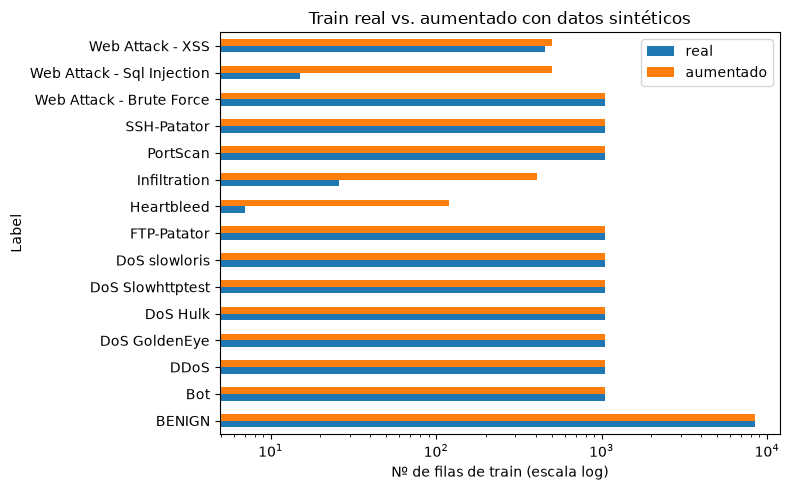

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
compare_counts = pd.DataFrame({
    "real": train_df["Label"].value_counts(),
    "aumentado": train_df_augmented["Label"].value_counts(),
}).fillna(0)
compare_counts.plot(kind="barh", ax=ax, logx=True)
ax.set_xlabel("Nº de filas de train (escala log)")
ax.set_title("Train real vs. aumentado con datos sintéticos")
fig.tight_layout()
fig.savefig(RESULTS_DIR_P3 / "train_augmentation.png", dpi=120)
plt.show()

train_df_augmented.to_parquet(PROCESSED_DIR / "train_augmented.parquet", index=False)


### 3.4 Reentrenamiento sobre el train aumentado (DNN manual + AutoML + NAS)

Mismo preprocesamiento que en la Parte 1, pero el `StandardScaler` se reajusta **solo sobre el
train aumentado** (val/test siguen siendo los mismos reales de siempre, transformados con este
nuevo scaler para evaluar de forma consistente). Se reutilizan `train_dnn`, `run_flaml_automl` y
`make_nas_objective` / `refit_best_nas_dnn` de las Partes 1 y 2 sin modificarlos.


epoch   0: train_loss=1.8236 val_loss=1.0603 train_f1=0.6202 val_f1=0.5351


epoch   5: train_loss=0.4722 val_loss=0.3163 train_f1=0.8036 val_f1=0.7065


epoch  10: train_loss=0.3523 val_loss=0.2600 train_f1=0.8292 val_f1=0.7235


epoch  15: train_loss=0.3150 val_loss=0.2366 train_f1=0.8505 val_f1=0.7585


epoch  20: train_loss=0.2793 val_loss=0.2455 train_f1=0.8407 val_f1=0.7547
Early stopping en epoch 20 (mejor val_f1=0.7705)
DNN manual sobre train aumentado (test): {'macro_f1': 0.7774509651975505, 'balanced_accuracy': 0.8742721088435375, 'best_val_macro_f1': 0.7705312921871689, 'n_params': 21263, 'epochs_run': 21}


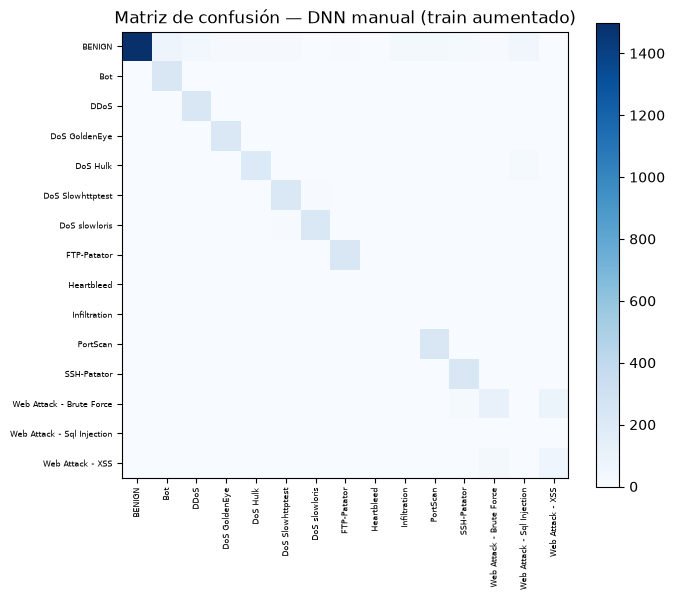

In [ ]:
scaler_aug = StandardScaler().fit(train_df_augmented[FEATURE_COLS])
X_train_aug = scaler_aug.transform(train_df_augmented[FEATURE_COLS]).astype(np.float32)
y_train_aug = label_encoder.transform(train_df_augmented["Label"])
X_val_aug = scaler_aug.transform(val_df[FEATURE_COLS]).astype(np.float32)
X_test_aug = scaler_aug.transform(test_df[FEATURE_COLS]).astype(np.float32)
# y_val / y_test son los mismos de siempre (las etiquetas no cambian de escala)

dnn_aug_model, dnn_aug_history, dnn_aug_best_val_f1 = train_dnn(
    X_train_aug, y_train_aug, X_val_aug, y_val, N_CLASSES, CONFIG["dnn"], DEVICE, CONFIG["seed"]
)
torch.save(dnn_aug_model.state_dict(), RESULTS_DIR_P3 / "dnn_augmented.pt")

dnn_aug_model.eval()
with torch.no_grad():
    pred_dnn_aug = dnn_aug_model(torch.tensor(X_test_aug).to(DEVICE)).argmax(1).cpu().numpy()

dnn_aug_metrics = {
    "macro_f1": float(f1_score(y_test, pred_dnn_aug, average="macro")),
    "balanced_accuracy": float(balanced_accuracy_score(y_test, pred_dnn_aug)),
    "best_val_macro_f1": float(dnn_aug_best_val_f1),
    "n_params": int(sum(p.numel() for p in dnn_aug_model.parameters())),
    "epochs_run": len(dnn_aug_history["train_loss"]),
}
print("DNN manual sobre train aumentado (test):", dnn_aug_metrics)
_ = plot_confusion(y_test, pred_dnn_aug, CLASS_NAMES, "Matriz de confusión — DNN manual (train aumentado)",
                    RESULTS_DIR_P3 / "confusion_matrix_dnn_augmented.png")


In [ ]:
automl_aug, pred_automl_aug, automl_aug_metrics = run_flaml_automl(
    X_train_aug, y_train_aug, X_val_aug, y_val, X_test_aug, y_test, CONFIG["automl"], CONFIG["seed"]
)
print("AutoML (FLAML) sobre train aumentado:", automl_aug_metrics)


/tmp/claude-1000/-home-alex-Git-Tareas-Deep-Learning/6c8135b8-1a85-444f-8550-9b87c98d04c9/scratchpad/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/tmp/claude-1000/-home-alex-Git-Tareas-Deep-Learning/6c8135b8-1a85-444f-8550-9b87c98d04c9/scratchpad/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/tmp/claude-1000/-home-alex-Git-Tareas-Deep-Learning/6c8135b8-1a85-444f-8550-9b87c98d04c9/scratchpad/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/tmp/claude-1000/-home-alex-Git-Tareas-Deep-Learning/6c8135b8-1a85-444f-8550-9b87c98d04c9/scratchpad/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/tmp/claude-1000/-home-alex-Git-Tareas-Deep-Learning/6c8135b8-1a85-444f-8550-9b87c98d04c9/scratchpad/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/tmp/claude-1000/-home-alex-Git-Tareas-Deep-Learning/6c8135b8-1a85-444f-8550-9b87c98d04c9/scratchpad/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/tmp/claude-1000/-home-alex-Git-Tareas-Deep-Learning/6c8135b8-1a85-444f-8550-9b87c98d04c9/scratchpad/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/tmp/claude-1000/-home-alex-Git-Tareas-Deep-Learning/6c8135b8-1a85-444f-8550-9b87c98d04c9/scratchpad/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


AutoML (FLAML) sobre train aumentado: {'best_estimator': 'kneighbor', 'best_config': {'n_neighbors': 1}, 'macro_f1': 0.9060516434473599, 'balanced_accuracy': 0.9104837490551776, 'train_time_s': 38.01788926124573}


In [ ]:
nas_objective_aug = make_nas_objective(
    X_train_aug, y_train_aug, X_val_aug, y_val, N_CLASSES, CONFIG["nas"], CONFIG["dnn"], DEVICE, CONFIG["seed"]
)
t0 = time.time()
study_aug = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=CONFIG["seed"]))
study_aug.optimize(nas_objective_aug, n_trials=CONFIG["nas"]["n_trials"], show_progress_bar=False)
nas_aug_search_time = time.time() - t0

nas_aug_model, pred_nas_aug, nas_aug_metrics = refit_best_nas_dnn(
    study_aug, CONFIG["nas"], CONFIG["dnn"], X_train_aug, y_train_aug, X_val_aug, y_val, X_test_aug, y_test,
    N_CLASSES, DEVICE, CONFIG["seed"], nas_aug_search_time, RESULTS_DIR_P3 / "nas_dnn_augmented.pt",
)
print("DNN + NAS sobre train aumentado (test):", nas_aug_metrics)


epoch   0: train_loss=2.9900 val_loss=2.6700 train_f1=0.1092 val_f1=0.1012


epoch   5: train_loss=2.1088 val_loss=1.9373 train_f1=0.4903 val_f1=0.4175


epoch  10: train_loss=1.6829 val_loss=1.4380 train_f1=0.5730 val_f1=0.4925


epoch   0: train_loss=1.8900 val_loss=1.0911 train_f1=0.5564 val_f1=0.4868


epoch   5: train_loss=0.6890 val_loss=0.4246 train_f1=0.7443 val_f1=0.6518


...

epoch  10: train_loss=0.2650 val_loss=0.2583 train_f1=0.8413 val_f1=0.7685


epoch  15: train_loss=0.2418 val_loss=0.2381 train_f1=0.8743 val_f1=0.7974


epoch  20: train_loss=0.2264 val_loss=0.2247 train_f1=0.8606 val_f1=0.7752


epoch  25: train_loss=0.2170 val_loss=0.2157 train_f1=0.8767 val_f1=0.7941


Early stopping en epoch 27 (mejor val_f1=0.8027)
DNN + NAS sobre train aumentado (test): {'hidden_dims': [64], 'dropout': 0.14046725484369038, 'lr': 0.001217284708112243, 'macro_f1': 0.7993852060141204, 'balanced_accuracy': 0.8872781557067272, 'best_val_macro_f1': 0.8027497971297376, 'n_params': 6095, 'epochs_run': 28, 'search_time_s': 57.90484023094177, 'final_train_time_s': 11.101125478744507}


### 3.5 Comparación final: datos reales vs. datos aumentados


In [ ]:
rows_p3 = rows + [
    {"modelo": "DNN manual (train aumentado)", "macro_f1_test": dnn_aug_metrics["macro_f1"],
     "n_params_o_reglas": dnn_aug_metrics["n_params"], "tiempo_entrenamiento_s": None,
     "gap_val_test": gap(dnn_aug_metrics["best_val_macro_f1"], dnn_aug_metrics["macro_f1"])},
    {"modelo": f"AutoML (train aumentado) — {automl_aug_metrics['best_estimator']}", "macro_f1_test": automl_aug_metrics["macro_f1"],
     "n_params_o_reglas": None, "tiempo_entrenamiento_s": automl_aug_metrics["train_time_s"], "gap_val_test": None},
    {"modelo": "DNN + NAS (train aumentado)", "macro_f1_test": nas_aug_metrics["macro_f1"],
     "n_params_o_reglas": nas_aug_metrics["n_params"], "tiempo_entrenamiento_s": nas_aug_metrics["final_train_time_s"],
     "gap_val_test": gap(nas_aug_metrics["best_val_macro_f1"], nas_aug_metrics["macro_f1"])},
]
comparison_final = pd.DataFrame(rows_p3)
comparison_final.to_csv(RESULTS_DIR_P3 / "comparison_table_final.csv", index=False)

summary_parte3 = {
    "synthetic_config": syn_cfg,
    "fidelity": fidelity_summary,
    "train_augmentation": {
        "n_real": len(train_df), "n_augmented": len(train_df_augmented),
        "n_synthetic_added": len(synthetic_added), "shortfall_warnings": shortfall_warnings,
    },
    "dnn_manual_augmented": dnn_aug_metrics,
    "automl_augmented": automl_aug_metrics,
    "nas_dnn_augmented": nas_aug_metrics,
    "comparison_table": rows_p3,
}
(RESULTS_DIR_P3 / "metrics.json").write_text(json.dumps(summary_parte3, indent=2, default=str))
comparison_final


,modelo,macro_f1_test,n_params_o_reglas,tiempo_entrenamiento_s,gap_val_test
0,Regresión Logística,0.726838,1155.0,3.450514,NaN
1,SVM (RBF),0.703991,4000.0,1.110446,NaN
2,DNN manual (Parte 1),0.752555,21263.0,NaN,0.0113
3,AutoML — extra_tree,0.884837,NaN,29.894167,NaN
4,DNN + NAS (Optuna),0.764950,6095.0,8.949894,0.0013
5,DNN manual (train aumentado),0.777451,21263.0,NaN,-0.0069
6,AutoML (train aumentado) — kneighbor,0.906052,NaN,38.017889,NaN
7,DNN + NAS (train aumentado),0.799385,6095.0,11.101125,0.0034


**Discusión (completar/ajustar con los números de la corrida final en el dataset completo):**

- Comparar fila a fila cada modelo "real" (Parte 2) contra su contraparte "train aumentado"
  (Parte 3): si el macro-F1 sube de forma consistente, el aumento sintético ayuda; si sube en
  algunos modelos y no en otros, sugiere que el efecto depende de cuánta capacidad tiene el
  modelo para aprovechar los datos sintéticos adicionales.
- Cruzar con `fidelity_summary["overall_score"]` (Sección 3.2): si el score de fidelidad es
  bajo, cualquier mejora o empeoramiento debe leerse con cautela — el generador podría estar
  introduciendo señal artificial en vez de reforzar patrones reales.
- El efecto debería notarse más en las clases minoritarias que fueron aumentadas
  (Heartbleed, Web Attack - Sql Injection, Infiltration, etc.): vale la pena mirar el **recall
  por clase** de esas categorías específicas en las matrices de confusión de esta sección versus
  las de la Parte 2, no solo el macro-F1 global.
- Si NAS/AutoML sobre datos aumentados no superan a la arquitectura manual aumentada, es
  evidencia de que el diseño manual (Sección 1.5) sigue siendo una base sólida incluso al
  cambiar la distribución de entrenamiento.


**Notas para la corrida final (en Colab, sobre el dataset completo):**

1. Subir los 8 CSV de CIC-IDS2017 a `Drive/IDS_Tarea1/data/raw/`.
2. Cambiar `CONFIG["fast_dev_run"] = False` y volver a ejecutar el notebook de punta a punta.
3. Los artefactos de esta corrida rápida quedan en `local_run/.../fast_dev/` y no interfieren
   con la corrida completa, que se guarda por separado en `.../processed/full/` — así se puede
   comparar ambas si es útil para el informe.
4. Subir `CONFIG["automl"]["time_budget_s"]`, `CONFIG["nas"]["n_trials"]` y
   `CONFIG["synthetic"]["tvae_epochs"]` (por ejemplo a varios minutos / 30-50 trials / varios
   cientos de épocas con GPU) una vez que el pipeline esté validado — los valores actuales son
   deliberadamente chicos para poder iterar rápido.
5. `CONFIG["synthetic"]["target_min_count_per_class"]` puede subirse bastante en la corrida
   completa: con ~2M filas de BENIGN, aumentar las clases raras a las pocas miles sigue siendo
   una fracción marginal del train total.
